# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/creditcard.csv")

In [9]:
print(df.shape) # taille du dataset
print(df.dtypes)
print(df.isnull().sum())  # valeurs manquantes
df.head()

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Répartition des classes

In [4]:
counts = df["Class"].value_counts()
print(counts)
print(f"\nFraudes : {counts[1]} ({counts[1]/len(df)*100:.2f}%)")
print(f"Normales : {counts[0]} ({counts[0]/len(df)*100:.2f}%)")


Class
0    284315
1       492
Name: count, dtype: int64

Fraudes : 492 (0.17%)
Normales : 284315 (99.83%)


/var/folders/d8/t1k6hm5j1v5d7mkbz5768s2c0000gn/T/ipykernel_14480/2772043070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette=["steelblue", "crimson"])


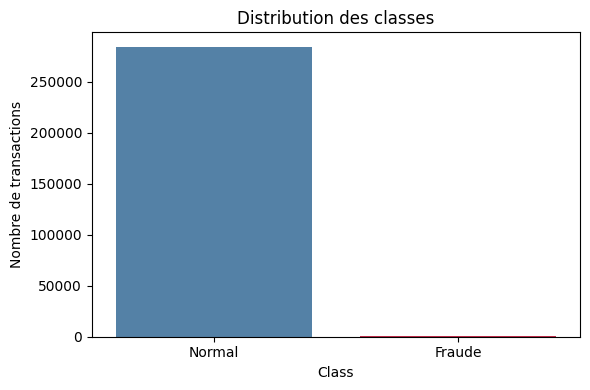

In [10]:
plt.figure(figsize=(6, 4))  # taille de la figure (largeur, hauteur)

sns.countplot(x="Class", data=df, palette=["steelblue", "crimson"])
# countplot = graphique à barres qui compte les occurrences
# x="Class"  → la colonne à compter 

plt.title("Distribution des classes")  # titre du graphique

plt.xticks([0, 1], ["Normal", "Fraude"])
# remplace les labels "0" et "1" sur l'axe X

plt.ylabel("Nombre de transactions") 

plt.tight_layout()  # ajuste les marges pour que rien ne soit coupé

plt.show()  

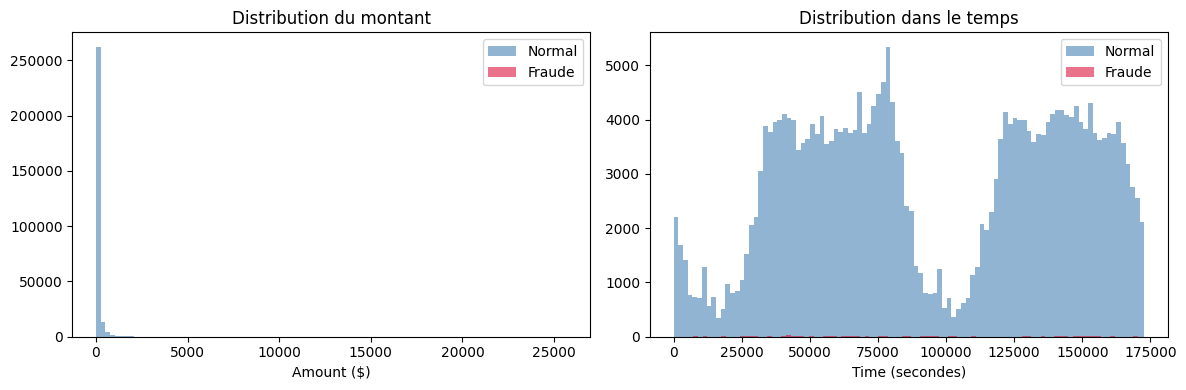

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# graphique de gauche
axes[0].hist(df[df["Class"] == 0]["Amount"], bins=100, alpha=0.6, label="Normal", color="steelblue")
axes[0].hist(df[df["Class"] == 1]["Amount"], bins=100, alpha=0.6, label="Fraude", color="crimson")
axes[0].set_title("Distribution du montant")
axes[0].set_xlabel("Amount ($)")
axes[0].legend()

# graphique de droite 
axes[1].hist(df[df["Class"] == 0]["Time"], bins=100, alpha=0.6, label="Normal", color="steelblue")
axes[1].hist(df[df["Class"] == 1]["Time"], bins=100, alpha=0.6, label="Fraude", color="crimson")
axes[1].set_title("Distribution dans le temps")
axes[1].set_xlabel("Time (secondes)")
axes[1].legend()

plt.tight_layout()
plt.show()

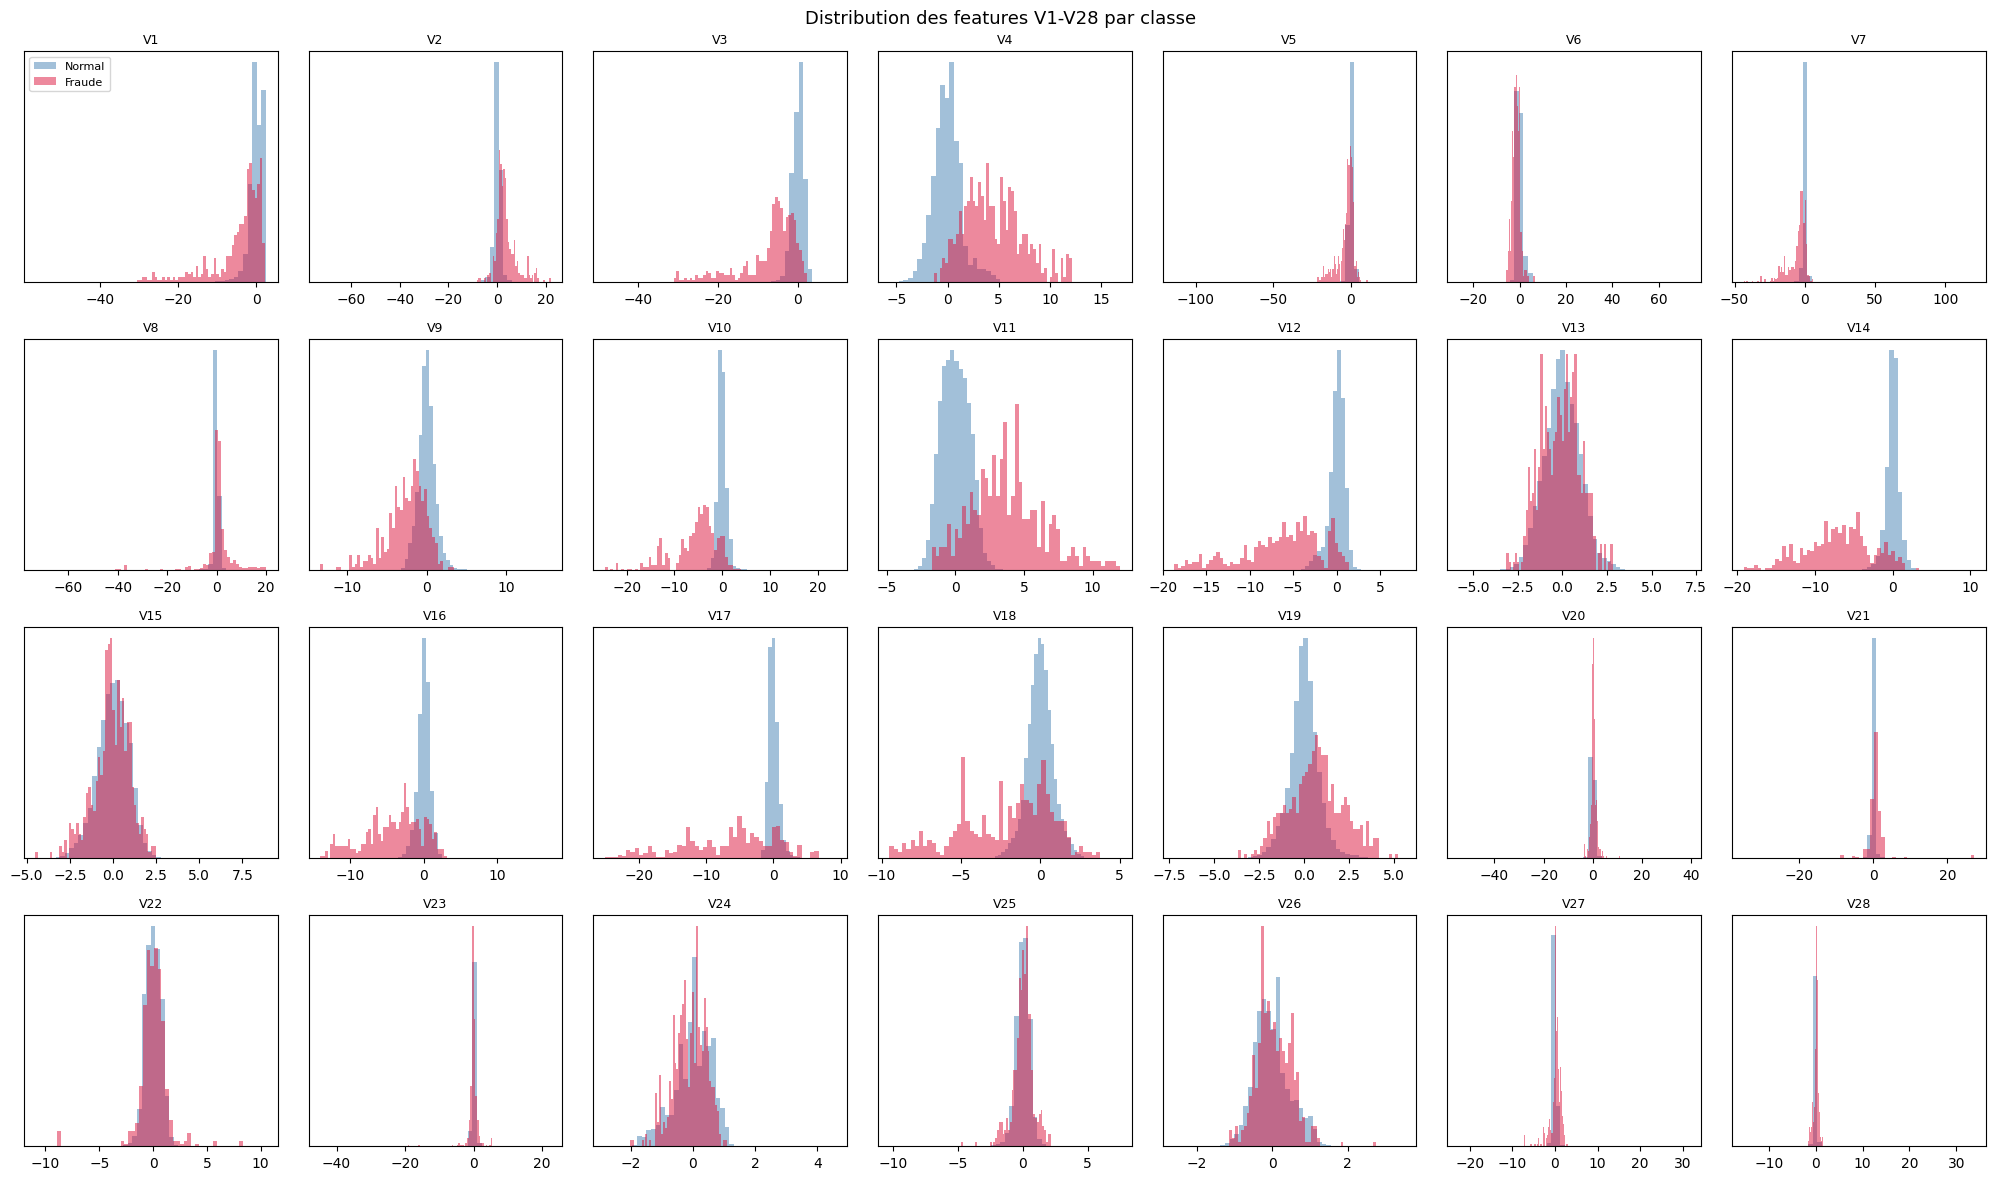

In [24]:
fig, axes = plt.subplots(4, 7, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate([f"V{j}" for j in range(1, 29)]):
    axes[i].hist(df[df["Class"]==0][col], bins=50,
                 alpha=0.5, label="Normal", color="steelblue", density=True)
    axes[i].hist(df[df["Class"]==1][col], bins=50,
                 alpha=0.5, label="Fraude", color="crimson", density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_yticks([])

axes[0].legend(fontsize=8)
plt.suptitle("Distribution des features V1-V28 par classe", fontsize=13)
plt.tight_layout()
plt.show()
#Permet de voir Feature par feature la répartitions de l'impact sur chaque classe

In [27]:
correlations = df.corr()["Class"].drop("Class").abs().sort_values(ascending=False) 
# Le résultat c'est un classement de toutes les features selon à quel point elles varient avec la classe  plus la valeur est proche de 1
# plus la feature distingue bien les fraudes des normales.
print(correlations)

V17       0.326481
V14       0.302544
V12       0.260593
V10       0.216883
V16       0.196539
V3        0.192961
V7        0.187257
V11       0.154876
V4        0.133447
V18       0.111485
V1        0.101347
V9        0.097733
V5        0.094974
V2        0.091289
V6        0.043643
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
Time      0.012323
V28       0.009536
V24       0.007221
Amount    0.005632
V13       0.004570
V26       0.004455
V15       0.004223
V25       0.003308
V23       0.002685
V22       0.000805
Name: Class, dtype: float64


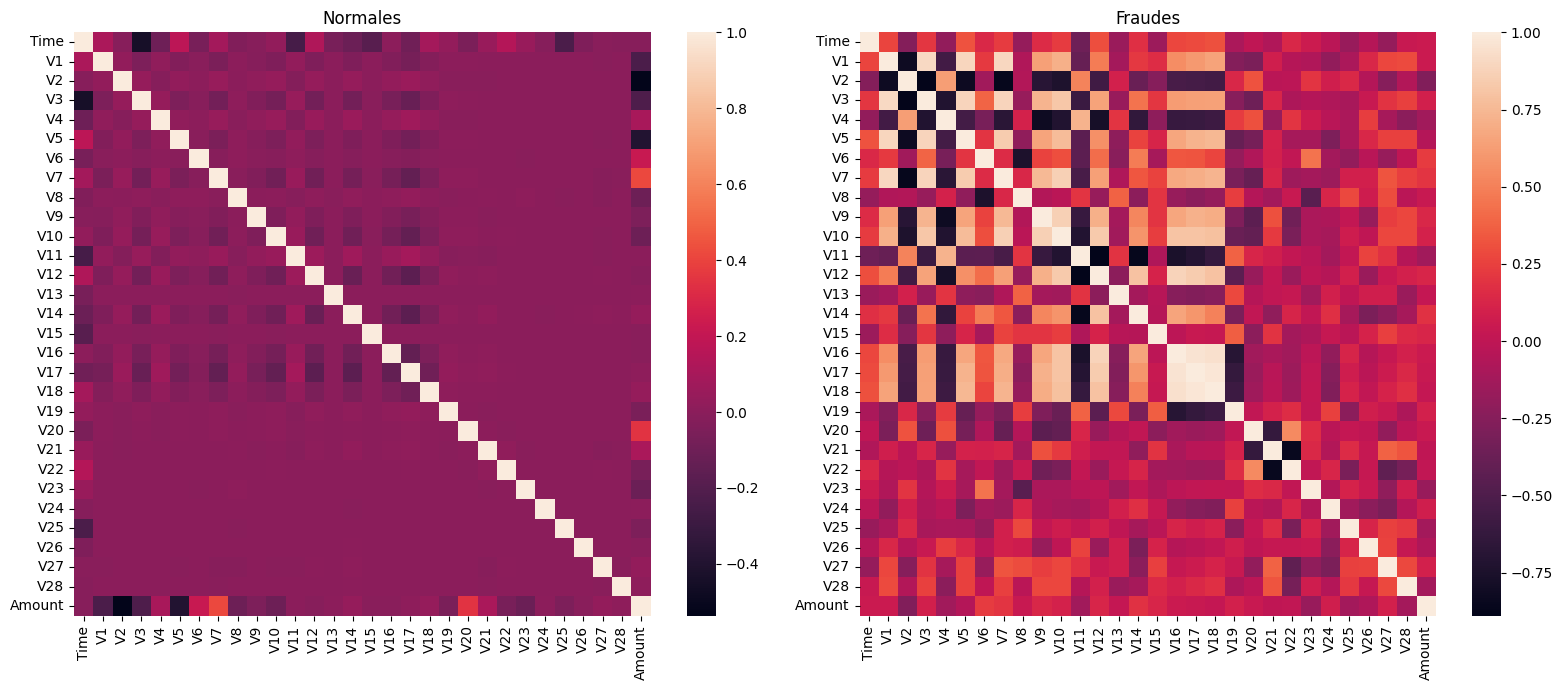

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))


sns.heatmap(df[df["Class"]==0].drop("Class", axis=1).corr(),ax=axes[0])
axes[0].set_title("Normales")
sns.heatmap(df[df["Class"]==1].drop("Class", axis=1).corr(),ax=axes[1])
axes[1].set_title("Fraudes")

plt.tight_layout()
plt.show()


/var/folders/d8/t1k6hm5j1v5d7mkbz5768s2c0000gn/T/ipykernel_14480/2623057003.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([normal_vals, fraud_vals],labels=["Normal", "Fraude"])
/var/folders/d8/t1k6hm5j1v5d7mkbz5768s2c0000gn/T/ipykernel_14480/2623057003.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([normal_vals, fraud_vals],labels=["Normal", "Fraude"])
/var/folders/d8/t1k6hm5j1v5d7mkbz5768s2c0000gn/T/ipykernel_14480/2623057003.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([normal_vals, fraud_vals],labels=["Normal", "Fraude"])
/var/folders/d8/t1k6hm5j1

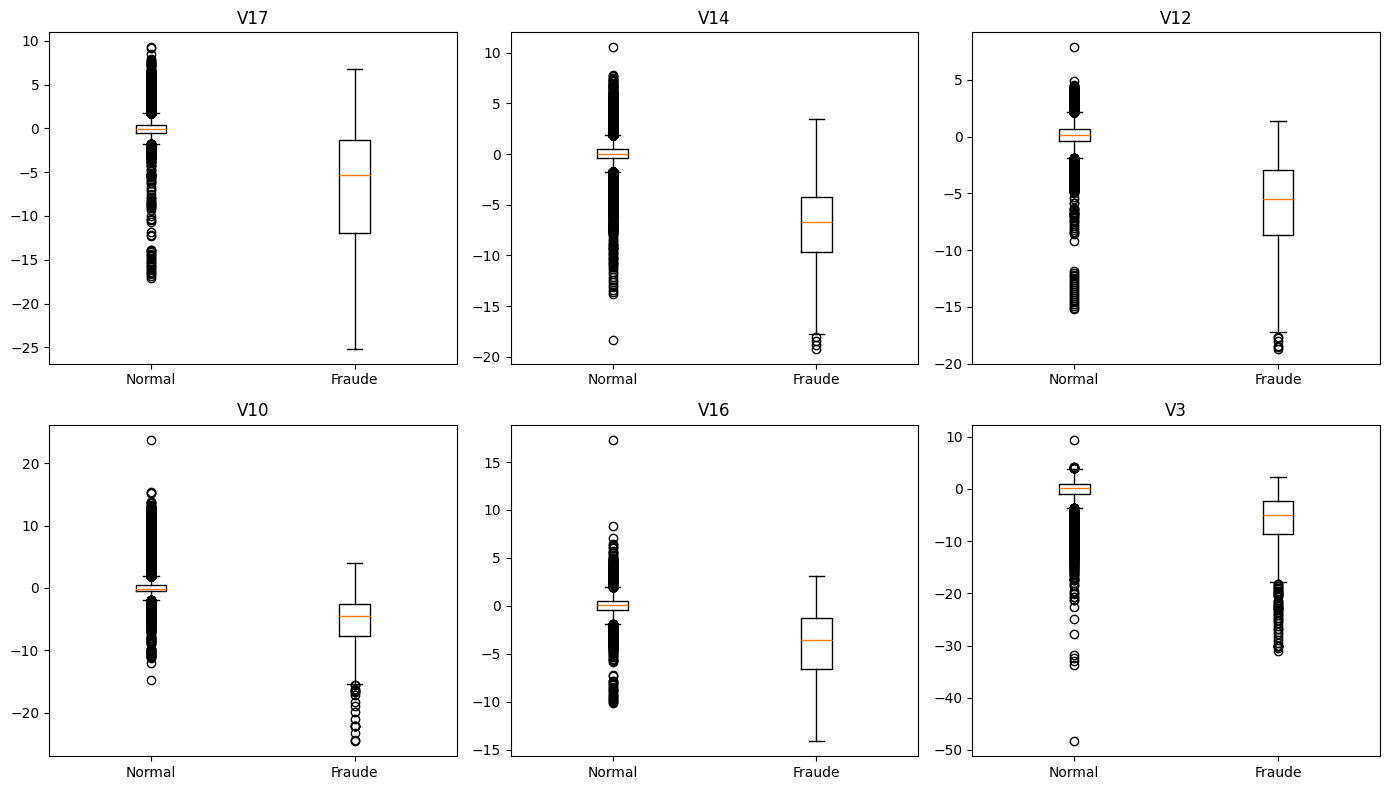

In [39]:
top_features = correlations.head(6).index.tolist() 

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    normal_vals = df[df["Class"]==0][feat]
    fraud_vals  = df[df["Class"]==1][feat]
    
    axes[i].boxplot([normal_vals, fraud_vals],labels=["Normal", "Fraude"])
    axes[i].set_title(feat)

plt.tight_layout()
plt.show()